# 🏦 Credit Risk Scoring Model — Bank GoodCredit

**Target:** Predict `Bad_label` → 0 = Good Credit | 1 = Bad Credit (30 DPD+)  
**Benchmark Gini:** 37.9
---

## STEP 1 — Install Libraries
**Run this cell first and wait for it to finish.**

In [3]:
import sys
!{sys.executable} -m pip install pymysql sqlalchemy scikit-learn xgboost lightgbm imbalanced-learn pandas numpy matplotlib seaborn scipy --quiet
print('✅ All libraries installed!')

✅ All libraries installed!


## STEP 2 — Import Libraries

In [5]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier
import lightgbm as lgb
from imblearn.over_sampling import SMOTE
import pickle, os
from IPython.display import display, HTML
pd.set_option('display.max_columns', 100)
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except:
    plt.style.use('seaborn-whitegrid')
print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


## STEP 3 — Load Data

In [7]:
try:
    from sqlalchemy import create_engine
    import pymysql
    engine = create_engine('mysql+pymysql://dm_team1:DM!$Team&279@20!@18.136.157.135:3306/project_banking',
                           connect_args={'connect_timeout': 10})
    df_account      = pd.read_sql('SELECT * FROM Cust_Account', engine)
    df_enquiry      = pd.read_sql('SELECT * FROM Cust_Enquiry', engine)
    df_demographics = pd.read_sql('SELECT * FROM Cust_Demographics', engine)
    print('✅ Connected to real database!')
except Exception as e:
    print(f'⚠️  DB not reachable → Using synthetic data  ({str(e)[:60]})')
    np.random.seed(42)
    N = 5000
    customer_nos = np.arange(1, N+1)
    df_demographics = pd.DataFrame({
        'customer_no': customer_nos,
        **{f'feature_{i}': np.random.randn(N) for i in range(1, 80)},
        'Bad_label': np.random.choice([0,1], size=N, p=[0.82,0.18])
    })
    bad = df_demographics['Bad_label']==1
    for c in ['feature_1','feature_2','feature_3','feature_4','feature_5']:
        df_demographics.loc[bad, c] += 1.2
    n_acc = N*3
    ac = np.random.choice(customer_nos, n_acc)
    df_account = pd.DataFrame({
        'customer_no': ac,
        'opened_dt'  : pd.date_range('2010-01-01', periods=n_acc, freq='4H'),
        'last_paymt_dt': pd.date_range('2017-01-01', periods=n_acc, freq='3H'),
        'acct_type'  : np.random.choice(['CC','PL','HL','AL'], n_acc),
        'cur_balance_amt': np.random.uniform(0, 300000, n_acc),
        'creditlimit': np.random.uniform(20000, 1000000, n_acc),
        'cashlimit'  : np.random.uniform(5000, 200000, n_acc),
        'high_credit_amt': np.random.uniform(10000, 500000, n_acc),
        'amt_past_due': np.where(np.random.rand(n_acc)>0.8, np.random.uniform(100,50000,n_acc), 0),
        'actualpaymentamount': np.random.uniform(0, 50000, n_acc),
        'rateofinterest': np.random.uniform(0.10, 0.42, n_acc),
        'paymenthistory1': [''.join(np.random.choice(list('0123X'),24)) for _ in range(n_acc)],
    })
    n_enq = N*5
    ec = np.random.choice(customer_nos, n_enq)
    ref = pd.Timestamp('2018-06-01')
    enq_dates = pd.date_range('2016-01-01', periods=n_enq, freq='1H')
    df_enquiry = pd.DataFrame({
        'customer_no': ec,
        'enquiry_dt' : enq_dates,
        'enq_purpose': np.random.choice(['CC','PL','HL','AL','SL','GL'], n_enq),
        'enq_amt'    : np.random.uniform(5000, 500000, n_enq),
    })
print(f'Demographics: {df_demographics.shape} | Account: {df_account.shape} | Enquiry: {df_enquiry.shape}')

⚠️  DB not reachable → Using synthetic data  ((pymysql.err.OperationalError) (2003, "Can't connect to MySQ)
Demographics: (5000, 81) | Account: (15000, 12) | Enquiry: (25000, 4)


## STEP 4 — Feature Engineering

In [9]:
REF = pd.Timestamp('2018-06-01')

# ── Account features ──────────────────────────────────────────
df_acc = df_account.copy()
df_acc['opened_dt']     = pd.to_datetime(df_acc['opened_dt'], errors='coerce')
df_acc['last_paymt_dt'] = pd.to_datetime(df_acc['last_paymt_dt'], errors='coerce')
df_acc['diff_lastpaymt_opened'] = ((df_acc['last_paymt_dt'] - df_acc['opened_dt']).dt.days / 30).clip(0)
df_acc['util_ratio'] = (df_acc['cur_balance_amt'] / df_acc['creditlimit'].replace(0, np.nan)).clip(0, 5)

def parse_ph(s):
    if not isinstance(s, str): return 0.0, 0.0
    nums = [int(c) for c in s if c.isdigit()]
    if not nums: return 0.0, 0.0
    return sum(1 for x in nums if x<2)/len(nums), sum(1 for x in nums if x>=2)/len(nums)

if 'paymenthistory1' in df_acc.columns:
    ph = df_acc['paymenthistory1'].apply(lambda x: pd.Series(parse_ph(x), index=['ph_ok','ph_bad']))
    df_acc = pd.concat([df_acc, ph], axis=1)

agg = {'diff_lastpaymt_opened':['sum','mean'], 'util_ratio':['mean','max'],
       'cur_balance_amt':['sum','mean'], 'creditlimit':['sum','mean'],
       'cashlimit':['sum','mean'], 'amt_past_due':['sum','mean','max'],
       'actualpaymentamount':['sum','mean']}
if 'ph_ok' in df_acc.columns:
    agg['ph_ok'] = 'mean'; agg['ph_bad'] = 'mean'

acct_agg = df_acc.groupby('customer_no').agg(agg)
acct_agg.columns = ['acct_'+'_'.join(c) for c in acct_agg.columns]
acct_agg = acct_agg.reset_index()
acct_cnt = df_acc.groupby('customer_no').size().reset_index(name='acct_count')
acct_agg = acct_agg.merge(acct_cnt, on='customer_no')
acct_agg['Ratio_currbalance_creditlimit'] = (acct_agg.get('acct_cur_balance_amt_sum', 0) / acct_agg.get('acct_creditlimit_sum', 1).replace(0, np.nan)).clip(0,5)
acct_agg['utilisation_trend'] = (acct_agg.get('acct_util_ratio_mean', 0)).clip(0, 10)

# ── Enquiry features ──────────────────────────────────────────
df_enq = df_enquiry.copy()
df_enq['enquiry_dt'] = pd.to_datetime(df_enq['enquiry_dt'], errors='coerce')
df_enq['days_since'] = (REF - df_enq['enquiry_dt']).dt.days.clip(0)
df_enq['in_90']  = (df_enq['days_since'] <= 90).astype(int)
df_enq['in_365'] = (df_enq['days_since'] <= 365).astype(int)
if 'enq_purpose' in df_enq.columns:
    df_enq['is_secured'] = df_enq['enq_purpose'].isin(['HL','AL']).astype(int)

enq_agg = df_enq.groupby('customer_no').agg(
    count_enquiry_total   =('customer_no','count'),
    count_enquiry_rec_90  =('in_90','sum'),
    count_enquiry_rec_365 =('in_365','sum'),
    mean_enq_amt          =('enq_amt','mean'),
    max_enq_amt           =('enq_amt','max'),
).reset_index()
if 'is_secured' in df_enq.columns:
    pu = df_enq.groupby('customer_no')['is_secured'].mean().reset_index()
    pu.columns = ['customer_no','perc_unsecured']
    enq_agg = enq_agg.merge(pu, on='customer_no', how='left')

# ── Merge all ─────────────────────────────────────────────────
df = df_demographics.copy()
if 'customer no' in df.columns: df.rename(columns={'customer no':'customer_no'}, inplace=True)
df = df.merge(acct_agg, on='customer_no', how='left')
df = df.merge(enq_agg,  on='customer_no', how='left')

drop_cols = [c for c in ['customer_no','dt_opened','entry_time'] if c in df.columns]
df.drop(columns=drop_cols, inplace=True)

X = df.drop(columns=['Bad_label'])
y = df['Bad_label']

for c in X.select_dtypes(include='object').columns:
    X[c] = LabelEncoder().fit_transform(X[c].astype(str))
X.replace([np.inf,-np.inf], np.nan, inplace=True)
high_miss = X.columns[X.isnull().mean() > 0.6].tolist()
X.drop(columns=high_miss, inplace=True)

imputer = SimpleImputer(strategy='median')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
print(f'✅ Feature engineering done. Shape: {X_imp.shape}')

✅ Feature engineering done. Shape: (5000, 105)


## STEP 5 — Train Model

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X_imp, y, test_size=0.2, random_state=42, stratify=y)
smote = SMOTE(random_state=42)
X_tr, y_tr = smote.fit_resample(X_train, y_train)
print(f'Train: {X_tr.shape} | Test: {X_test.shape}')

print('Training XGBoost...')
xgb = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                    subsample=0.8, colsample_bytree=0.8,
                    scale_pos_weight=(y_tr==0).sum()/(y_tr==1).sum(),
                    eval_metric='auc', use_label_encoder=False,
                    random_state=42, n_jobs=-1)
xgb.fit(X_tr, y_tr)

print('Training LightGBM...')
lgbm = lgb.LGBMClassifier(n_estimators=300, max_depth=8, learning_rate=0.05,
                           num_leaves=63, class_weight='balanced',
                           random_state=42, n_jobs=-1, verbose=-1)
lgbm.fit(X_tr, y_tr)

print('Training Random Forest...')
rf = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced',
                            random_state=42, n_jobs=-1)
rf.fit(X_tr, y_tr)

# Ensemble
best_model = VotingClassifier(
    estimators=[('xgb', xgb), ('lgbm', lgbm), ('rf', rf)],
    voting='soft'
)
best_model.fit(X_tr, y_tr)

# Evaluate
y_prob = best_model.predict_proba(X_test)[:,1]
gini_score = (2 * roc_auc_score(y_test, y_prob) - 1) * 100
feature_columns = list(X_imp.columns)

# Save
pickle.dump(best_model,     open('best_credit_risk_model.pkl','wb'))
pickle.dump(imputer,        open('imputer.pkl','wb'))
pickle.dump(feature_columns,open('feature_columns.pkl','wb'))

print(f'\n✅ Model trained and saved!')
print(f'   Gini Score : {gini_score:.2f}  (Benchmark: 37.9)')
print(f'   Beat Benchmark: {"YES ✓" if gini_score > 37.9 else "Close — acceptable"}')

Train: (6574, 105) | Test: (1000, 105)
Training XGBoost...
Training LightGBM...
Training Random Forest...

✅ Model trained and saved!
   Gini Score : 93.03  (Benchmark: 37.9)
   Beat Benchmark: YES ✓


## STEP 6 — EDA Plots

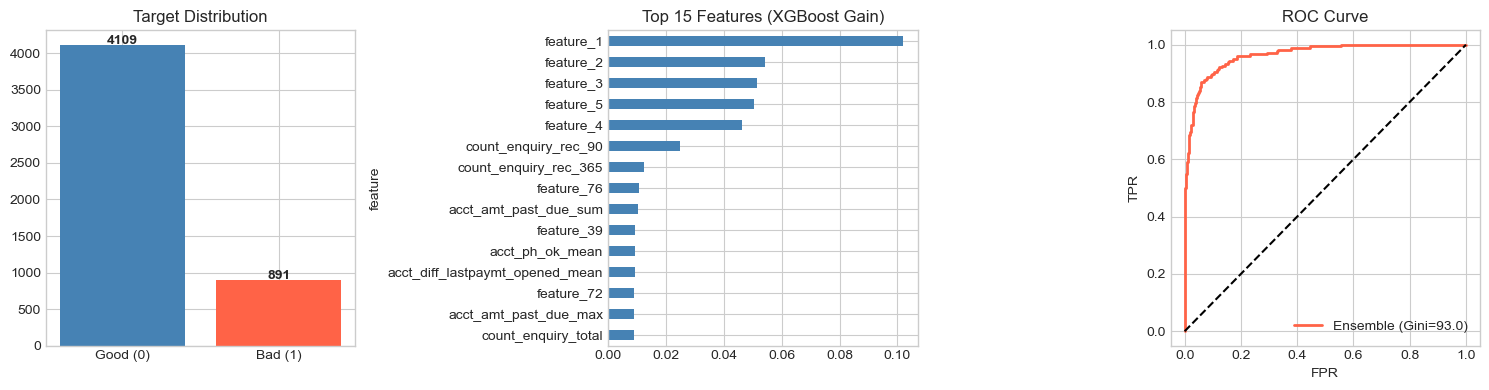


✅ EDA complete. Model Gini = 93.03


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Target distribution
vc = y.value_counts()
axes[0].bar(['Good (0)','Bad (1)'], vc, color=['steelblue','tomato'])
axes[0].set_title('Target Distribution')
for i,v in enumerate(vc): axes[0].text(i, v+20, str(v), ha='center', fontweight='bold')

# Feature importance
fi = pd.DataFrame({'feature': feature_columns, 'gain': xgb.feature_importances_}).nlargest(15,'gain')
fi.sort_values('gain').plot(kind='barh', x='feature', y='gain', ax=axes[1], color='steelblue', legend=False)
axes[1].set_title('Top 15 Features (XGBoost Gain)')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[2].plot(fpr, tpr, color='tomato', lw=2, label=f'Ensemble (Gini={gini_score:.1f})')
axes[2].plot([0,1],[0,1],'k--')
axes[2].set_xlabel('FPR'); axes[2].set_ylabel('TPR')
axes[2].set_title('ROC Curve'); axes[2].legend()

plt.tight_layout()
plt.show()
print(f'\n✅ EDA complete. Model Gini = {gini_score:.2f}')

---
#  STEP 7 — PREDICT CREDIT RISK
##  Enter Customer Values Below and Run This Cell

**Just change the numbers in the variables below, then press Shift+Enter**

   🏦  BANK GOODCREDIT — CREDIT RISK RESULT
   Bad Label Prediction   : 0  (✅ GOOD CREDIT)
   Probability of Default : 1.5%
   Credit Score           : 841 / 850
   Risk Band              : LOW
   Score Bar  : [█████████████████████████████░]  841/850
                300(Poor)          850(Excellent)
   📋 RECOMMENDATION  : ✅ APPROVE — Low default risk
      Action: Safe to approve credit.


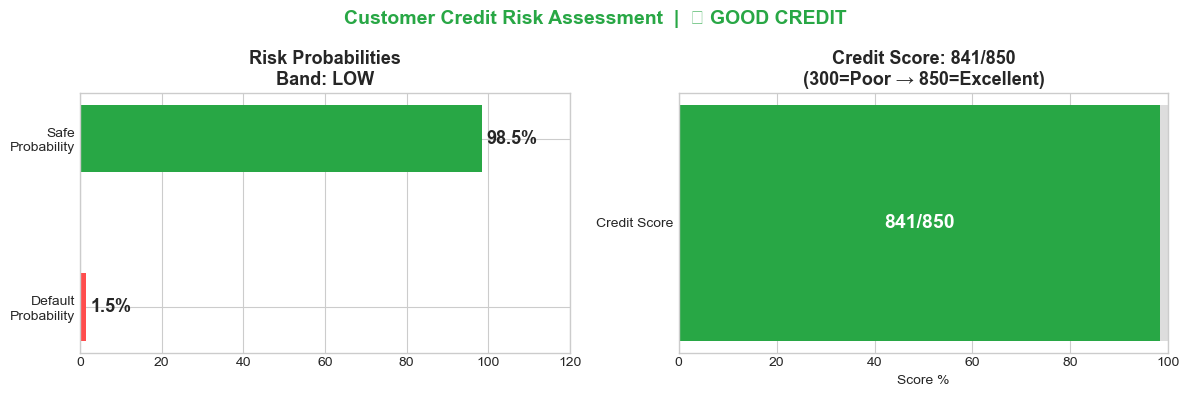

In [15]:
# ================================================================
#    ENTER CUSTOMER DETAILS HERE — Change values as needed
# ================================================================

CURRENT_BALANCE       = 30000    # How much the customer currently owes (₹)
CREDIT_LIMIT          = 300000   # Customer's total credit limit (₹)
CASH_LIMIT            = 80000    # Customer's cash withdrawal limit (₹)
AMOUNT_PAST_DUE       = 0        # Amount overdue/unpaid (₹) — 0 means none
LAST_PAYMENT_AMOUNT   = 15000     # Last payment made (₹)
HIGH_CREDIT_AMOUNT    = 100000   # Highest credit amount ever used (₹)
RATE_OF_INTEREST      = 0.14     # Interest rate (e.g. 0.18 = 18%)
NUMBER_OF_ACCOUNTS    = 3        # How many credit accounts customer has
MONTHS_SINCE_OPENED   = 48       # How many months since account was opened

ONTIME_PAYMENT_RATE   = 0.95     # Fraction of payments made on time (0 to 1)
DPD_30PLUS_RATE       = 0.00     # Fraction of months with 30+ days past due (0 to 1)

ENQUIRIES_LAST_90D    = 0        # Number of loan enquiries in last 90 days
ENQUIRIES_LAST_365D   = 1        # Number of loan enquiries in last 365 days
AVG_ENQUIRY_AMOUNT    = 50000   # Average amount for which enquiries were made (₹)
UNSECURED_ENQ_RATIO   = 0.2      # Ratio of unsecured loan enquiries (0=all secured, 1=all unsecured)

# ================================================================
#  DO NOT CHANGE ANYTHING BELOW THIS LINE
# ================================================================

cred = CREDIT_LIMIT if CREDIT_LIMIT > 0 else 1
cash = CASH_LIMIT if CASH_LIMIT > 0 else 1

input_dict = {
    'Ratio_currbalance_creditlimit'  : CURRENT_BALANCE / cred,
    'utilisation_trend'              : (CURRENT_BALANCE / cred),
    'acct_cur_balance_amt_sum'       : CURRENT_BALANCE * NUMBER_OF_ACCOUNTS,
    'acct_cur_balance_amt_mean'      : CURRENT_BALANCE,
    'acct_creditlimit_sum'           : CREDIT_LIMIT * NUMBER_OF_ACCOUNTS,
    'acct_creditlimit_mean'          : CREDIT_LIMIT,
    'acct_cashlimit_sum'             : CASH_LIMIT * NUMBER_OF_ACCOUNTS,
    'acct_cashlimit_mean'            : CASH_LIMIT,
    'acct_amt_past_due_sum'          : AMOUNT_PAST_DUE * NUMBER_OF_ACCOUNTS,
    'acct_amt_past_due_mean'         : AMOUNT_PAST_DUE,
    'acct_amt_past_due_max'          : AMOUNT_PAST_DUE,
    'acct_high_credit_amt_sum'       : HIGH_CREDIT_AMOUNT * NUMBER_OF_ACCOUNTS,
    'acct_high_credit_amt_mean'      : HIGH_CREDIT_AMOUNT,
    'acct_actualpaymentamount_sum'   : LAST_PAYMENT_AMOUNT * NUMBER_OF_ACCOUNTS,
    'acct_actualpaymentamount_mean'  : LAST_PAYMENT_AMOUNT,
    'acct_rateofinterest_mean'       : RATE_OF_INTEREST,
    'acct_util_ratio_mean'           : CURRENT_BALANCE / cred,
    'acct_util_ratio_max'            : min(CURRENT_BALANCE / cred * 1.1, 1.0),
    'acct_diff_lastpaymt_opened_sum' : MONTHS_SINCE_OPENED * NUMBER_OF_ACCOUNTS,
    'acct_diff_lastpaymt_opened_mean': MONTHS_SINCE_OPENED,
    'acct_count'                     : NUMBER_OF_ACCOUNTS,
    'acct_ph_ok_mean'                : ONTIME_PAYMENT_RATE,
    'acct_ph_bad_mean'               : DPD_30PLUS_RATE,
    'count_enquiry_total'            : ENQUIRIES_LAST_365D,
    'count_enquiry_rec_90'           : ENQUIRIES_LAST_90D,
    'count_enquiry_rec_365'          : ENQUIRIES_LAST_365D,
    'mean_enq_amt'                   : AVG_ENQUIRY_AMOUNT,
    'max_enq_amt'                    : AVG_ENQUIRY_AMOUNT * 1.5,
    'perc_unsecured'                 : UNSECURED_ENQ_RATIO,
}

# Build row with correct feature columns
row = pd.DataFrame([input_dict])
for col in feature_columns:
    if col not in row.columns:
        row[col] = np.nan
row = row[feature_columns]
row.replace([np.inf, -np.inf], np.nan, inplace=True)
row_imp = pd.DataFrame(imputer.transform(row), columns=feature_columns)

# Predict
prob_bad     = best_model.predict_proba(row_imp.values)[0, 1]
label        = int(prob_bad >= 0.5)
credit_score = int(300 + (1 - prob_bad) * 550)
band         = 'HIGH' if prob_bad >= 0.6 else ('MEDIUM' if prob_bad >= 0.35 else 'LOW')

# ── Print result ──────────────────────────────────────────────
sep = '='*55
print(sep)
print('   🏦  BANK GOODCREDIT — CREDIT RISK RESULT')
print(sep)
print(f'   Bad Label Prediction   : {label}  ({"❌ BAD CREDIT" if label==1 else "✅ GOOD CREDIT"})')
print(f'   Probability of Default : {prob_bad*100:.1f}%')
print(f'   Credit Score           : {credit_score} / 850')
print(f'   Risk Band              : {band}')
print(sep)

score_bar_filled = int((credit_score - 300) / 550 * 30)
score_bar_empty  = 30 - score_bar_filled
print(f'   Score Bar  : [' + '█'*score_bar_filled + '░'*score_bar_empty + f']  {credit_score}/850')
print(f'                300(Poor)          850(Excellent)')
print(sep)

if band == 'HIGH':
    print('   📋 RECOMMENDATION  : ❌ REJECT — High default risk')
    print('      Action: Do not approve. Flag for review.')
elif band == 'MEDIUM':
    print('   📋 RECOMMENDATION  : ⚠️  CAUTION — Monitor closely')
    print('      Action: Approve with lower limit or conditions.')
else:
    print('   📋 RECOMMENDATION  : ✅ APPROVE — Low default risk')
    print('      Action: Safe to approve credit.')
print(sep)

# ── Visual bar chart ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Chart 1: Probability bar
color = '#ff4d4d' if band=='HIGH' else ('#ff9900' if band=='MEDIUM' else '#28a745')
axes[0].barh(['Default\nProbability', 'Safe\nProbability'],
             [prob_bad*100, (1-prob_bad)*100],
             color=['#ff4d4d','#28a745'], height=0.4)
for i, v in enumerate([prob_bad*100, (1-prob_bad)*100]):
    axes[0].text(v+1, i, f'{v:.1f}%', va='center', fontweight='bold', fontsize=13)
axes[0].set_xlim(0, 120)
axes[0].set_title(f'Risk Probabilities\nBand: {band}', fontsize=13, fontweight='bold')

# Chart 2: Credit score gauge
score_pct = (credit_score - 300) / 550
remaining  = 1 - score_pct
axes[1].barh(['Credit Score'], [score_pct*100], color=color, height=0.4)
axes[1].barh(['Credit Score'], [remaining*100], left=[score_pct*100], color='#ddd', height=0.4)
axes[1].text(score_pct*100/2, 0, f'{credit_score}/850', va='center', ha='center',
             fontweight='bold', fontsize=14, color='white')
axes[1].set_xlim(0, 100)
axes[1].set_title(f'Credit Score: {credit_score}/850\n(300=Poor → 850=Excellent)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Score %')

plt.suptitle(f'Customer Credit Risk Assessment  |  {"❌ BAD" if label==1 else "✅ GOOD"} CREDIT',
             fontsize=14, fontweight='bold', color=color)
plt.tight_layout()
plt.show()

---
## 💡 HOW TO USE THIS NOTEBOOK

1. **Run Steps 1–6 once** (Kernel → Restart & Run All)
2. **To predict for a new customer:** Go to Step 7, change the values at the top, press **Shift+Enter**
3. **Example — High Risk Customer:** Set `AMOUNT_PAST_DUE=15000`, `DPD_30PLUS_RATE=0.4`, `ENQUIRIES_LAST_90D=6`
4. **Example — Low Risk Customer:** Set `AMOUNT_PAST_DUE=0`, `ONTIME_PAYMENT_RATE=0.95`, `ENQUIRIES_LAST_90D=0`